# Data Cleaning in Python — Exercise

**Course:** Intro to Data Mining  
**Dataset:** Heart Failure Prediction dataset (loaded from a public URL — no file downloads needed!)  

---


# YOUR TURN: Practice Exercise

Now apply the same data cleaning pipeline from the Titanic exercise to a **new dataset**: the **Heart Failure Prediction** dataset.

This dataset combines 5 heart disease databases (918 patients total) and contains medical information about patients and whether or not they have heart disease. It has **text columns that need encoding**, potential outliers, and some tricky data quality issues — perfect for practicing everything we just learned.

**Your tasks** (follow the same steps from above):

1. Load the data and take a first look
2. Understand the data types and structure
3. Get descriptive statistics
4. Check for duplicates
5. Handle missing values (decide: drop column, drop row, or impute?)
6. Encode any categorical (`object`) columns
7. Detect and handle outliers
8. Scale the numerical features

The starter code below loads the dataset for you. The rest is up to you!

> **Hints:** Pay close attention to `.describe()` — not all missing values show up as NaN! Also, this dataset was made by combining multiple hospital databases, so check for duplicates.

### About the Heart Failure Prediction Dataset

| Column | Description | Type |
|--------|-------------|------|
| Age | Age in years | Numerical |
| Sex | M = Male, F = Female | Categorical |
| ChestPainType | TA = Typical Angina, ATA = Atypical Angina, NAP = Non-Anginal Pain, ASY = Asymptomatic | Categorical |
| RestingBP | Resting blood pressure (mm Hg) | Numerical |
| Cholesterol | Serum cholesterol (mg/dl) | Numerical |
| FastingBS | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Numerical |
| RestingECG | Normal, ST = ST-T wave abnormality, LVH = left ventricular hypertrophy | Categorical |
| MaxHR | Maximum heart rate achieved | Numerical |
| ExerciseAngina | Y = Yes, N = No | Categorical |
| Oldpeak | ST depression induced by exercise | Numerical |
| ST_Slope | Up = upsloping, Flat = flat, Down = downsloping | Categorical |
| HeartDisease | 1 = heart disease, 0 = no heart disease (TARGET) | Numerical |

### Step 1: Load the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# The Heart Failure Prediction dataset — loaded from a public GitHub URL
# (Originally from Kaggle, combining 5 UCI heart disease databases)
url = 'https://raw.githubusercontent.com/xpy-10/DataSet/main/heart.csv'

heart = pd.read_csv(url)

print(f'Dataset shape: {heart.shape[0]} rows x {heart.shape[1]} columns')
heart.head()

Dataset shape: 918 rows x 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


### Step 2: Check data types and structure

Use `.info()` to see the data types and count non-null values.

In [4]:
# Hint: heart.info()
print("/nINFO:")
heart.info()

print("/nData types:")
print(heart.dtypes)

print("/nMissing values (NaN) per column:")
display(heart.isna().sum())

/nINFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
/nData types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         objec

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


### Step 3: Descriptive statistics

Use `.describe()`. Look for anything surprising in the min, max, or mean values.

In [5]:
# Hint: heart.describe()
heart.describe(include='object')



,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


### Step 4: Check for duplicates

How many duplicate rows are there? If any, remove them.

In [6]:
# YOUR CODE HERE
# Hint: heart.duplicated().sum()
# To remove: heart = heart.drop_duplicates()
heart = heart.drop_duplicates()
heart.duplicated().sum()


np.int64(0)

### Step 5: Handle missing values

Check the percentage of missing values per column. Then decide what to do:
- Drop columns that are mostly missing
- Drop rows if very few are missing
- Impute (fill) with mean or median if a moderate amount is missing

In [7]:
# YOUR CODE HERE
# Step 1: Find missing value percentages
# Hint: (heart.isnull().sum() / len(heart)) * 100

# Step 2: Decide and apply your strategy for each column with missing values

missing_percent = (heart.isnull().sum() / len(heart)) * 100
print("Missing % (NaN):")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

suspect_cols = ["Cholestrol", "RestingBP"]

for col in suspect_cols:
  if col in heart.columns:
    heart.loc[heart[col] == 0, col] = np.nan

  missing_percent2 = (heart.isnull().sum() / len(heart)) * 100
  print("/nMissing % after converting hiddenzeros to NaN:")
  print(missing_percent2[missing_percent2 > 0].sort_values(ascending=False))

  num_cols = heart.select_dtypes(include="number").columns
  obj_cols = heart.select_dtypes(include="object").columns

  for col in num_cols:
    if heart[col].isnull().sum() > 0:
             heart[col] = heart[col].fillna(heart[col].mode()[0])

  print("/nRemaining missing values:")
  print(heart.isnull().sum())


Missing % (NaN):
Series([], dtype: float64)
/nMissing % after converting hiddenzeros to NaN:
Series([], dtype: float64)
/nRemaining missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
/nMissing % after converting hiddenzeros to NaN:
RestingBP    0.108932
dtype: float64
/nRemaining missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


### Step 6: Encode categorical variables

Check if any columns are `object` type. If so, decide whether to use label encoding or one-hot encoding.

Hint: Look at `.info()` output — how many unique values does each `object` column have?

In [8]:
# YOUR CODE HERE
# Hint: Check for object columns with:
# heart.select_dtypes(include='object').columns
#
# For 2 categories: heart['col'] = heart['col'].map({'val1': 0, 'val2': 1})
# For 3+ categories: heart = pd.get_dummies(heart, columns=['col'], drop_first=True)
#
# Think about which columns have 2 categories vs. 3+ categories

cat_cols = heart.select_dtypes(include="object").columns
print("Categorical columns:", list(cat_cols))

binary_cols = [col for col in cat_cols if heart[col].nunique() == 2]
multi_cols = [col for col in cat_cols if heart[col].nunique() > 2]

print("Binary columns", binary_cols)
print("Multi-category columns:", multi_cols)

for col in binary_cols:
  vals = heart[col].unique()
  heart[col] = heart[col].map({vals[0]: 0, vals[1]: 1})

heart = pd.get_dummies(heart, columns=multi_cols, drop_first=True)

heart.head()


Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Binary columns ['Sex', 'ExerciseAngina']
Multi-category columns: ['ChestPainType', 'RestingECG', 'ST_Slope']


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140.0,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,1,160.0,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,0,130.0,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,1,138.0,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,0,150.0,195,0,122,0,0.0,0,False,True,False,True,False,False,True


### Step 7: Detect and handle outliers

Pick 2-3 numerical columns (e.g., `trestbps`, `chol`, `thalach`). Create box plots and use the IQR method.

Remember: think about whether outliers are real data or errors before removing them!

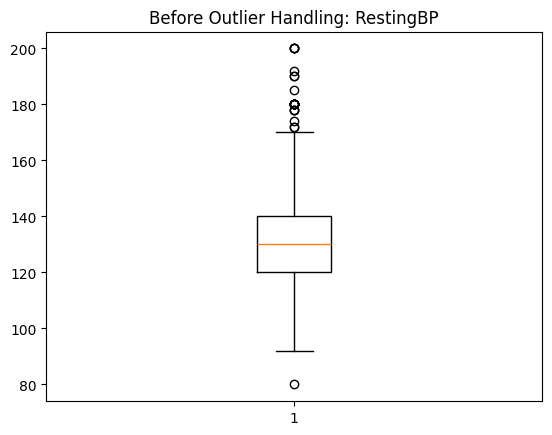

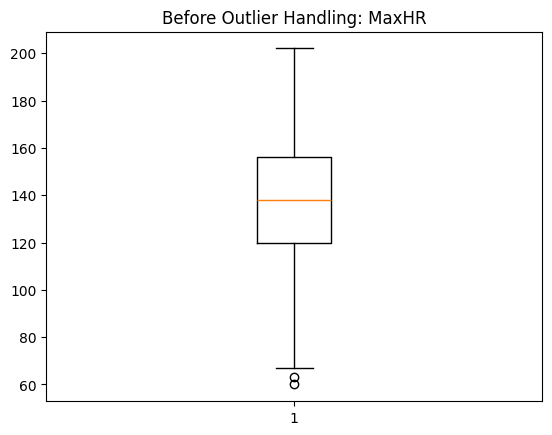

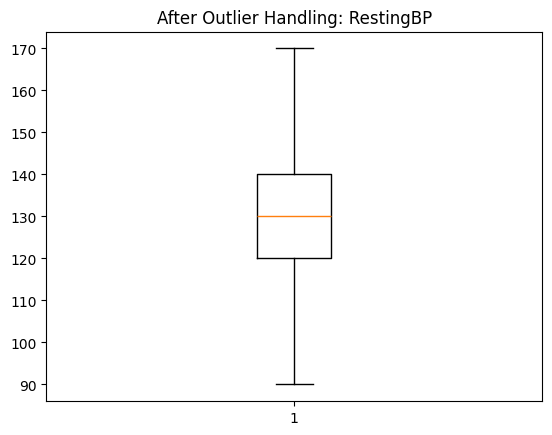

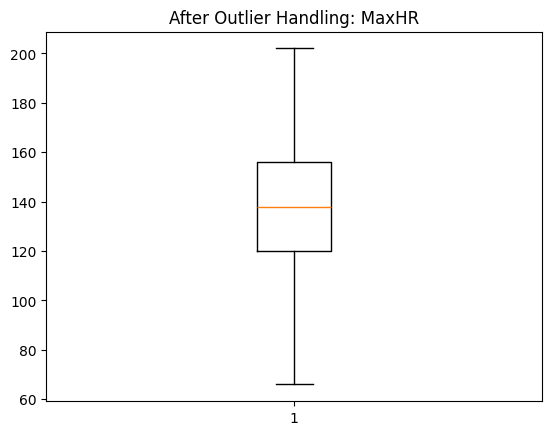

In [9]:
# YOUR CODE HERE
# Hint: You can reuse the detect_outliers_iqr function from above
# Then create box plots with plt.boxplot()

import matplotlib.pyplot as plt

cols = ["RestingBP", "Cholestrol", "MaxHR"]

for col in cols:
  if col in heart.columns:
    plt.figure()
    plt.boxplot(heart[col])
    plt.title(f"Before Outlier Handling: {col}")
    plt.show()

for col in cols:
  if col in heart.columns:
    Q1 = heart[col].quantile(0.25)
    Q3 = heart[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    heart[col] = heart[col].clip(lower,upper)
for col in cols:
  if col in heart.columns:
    plt.figure()
    plt.boxplot(heart[col])
    plt.title(f"After Outlier Handling: {col}")
    plt.show()


### Step 8: Scale the numerical features

Apply Min-Max scaling to the numerical columns (not the target column).

In [10]:
# YOUR CODE HERE
# Hint: Follow the same pattern from Section 8 of the tutorial

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X = heart.drop("HeartDisease", axis=1)
y = heart["HeartDisease"]

num_cols = X.select_dtypes(include="number").columns

X[num_cols] = scaler.fit_transform(X[num_cols])

heart_scaled = pd.concat([X, y], axis=1)

heart_scaled.head()


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up,HeartDisease
0,0.244898,0.0,0.625,0.479270,0.0,0.779412,0.0,0.295455,True,False,False,True,False,False,True,0
1,0.428571,1.0,0.875,0.298507,0.0,0.661765,0.0,0.409091,False,True,False,True,False,True,False,1
2,0.183673,0.0,0.500,0.469320,0.0,0.235294,0.0,0.295455,True,False,False,False,True,False,True,0
3,0.408163,1.0,0.600,0.354892,0.0,0.308824,1.0,0.465909,False,False,False,True,False,True,False,1
4,0.530612,0.0,0.750,0.323383,0.0,0.411765,0.0,0.295455,False,True,False,True,False,False,True,0


### Reflection Questions

After completing the exercise, answer these questions (add a text cell or answer here):

1. How did the Heart Disease dataset compare to the Titanic dataset in terms of data quality?

ANSWER: The Heart Disease dataset had fewer obvious missing values than the Titanic dataset, but it had missing values such as zero values in columns like cholestrol and resting BP. It required more attention to numerical outliers, while Titanic required more categorical cleaning of obvious missing data like age and cabin

2. Which missing value strategy did you use, and why?

ANSWER:I converted hidden zero values to NaN and used median for numerical columns because medical variables are often skewed. For categorical variables, I used mode. This preserves the overall distribution and reduces the influence of extreme values

3. Did you find any outliers? Did you remove them? Why or why not?

ANSWER: Yes, I found outliers in variables such as cholestrol and resting BP. instead of removing rows, I capped extreme values using the IQR method. I chose not to delete rows because in medical datasets, extreme values can still represent real patients

4. If you were building a model to predict heart disease, which columns do you think would be most important?

ANSWER: Age, Cholestrol, RestingBP, MaxHR,ChestPainType, ExcerciseAngina and ST_Slope would likely be most important because they are clinically related to cardiovascuar health and known risk factors for heart disease

---
*Great work! You now have hands-on experience with a complete data cleaning pipeline.* Dr. Thompson